Detected target column: 'sex'

   EXPERIMENTS FOR Heart Disease (Tabular)

n=1 | Accuracy=0.7833 | Time=2.662s
n=10 | Accuracy=0.7500 | Time=1.209s
n=50 | Accuracy=0.7667 | Time=3.388s
n=100 | Accuracy=0.7833 | Time=1.472s
n=300 | Accuracy=0.7833 | Time=2.683s


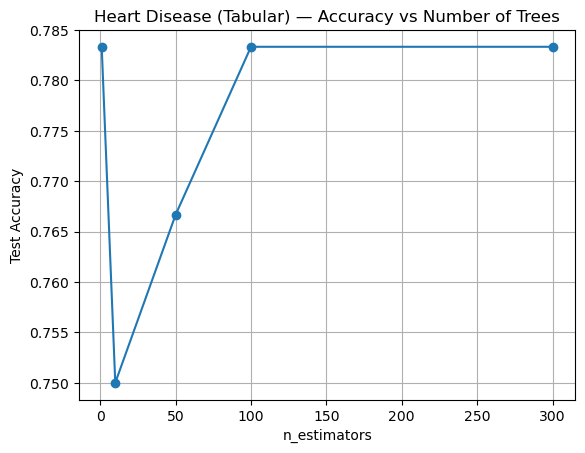


----- COMPARISON -----
Decision Tree: Accuracy=0.7500, Time=0.0000s
Random Forest: Accuracy=0.8000, Time=0.7590s
Reading image files...
Loading category: buildings
Loading category: forest
Loading category: glacier
Loading category: mountain
Loading category: sea
Loading category: street


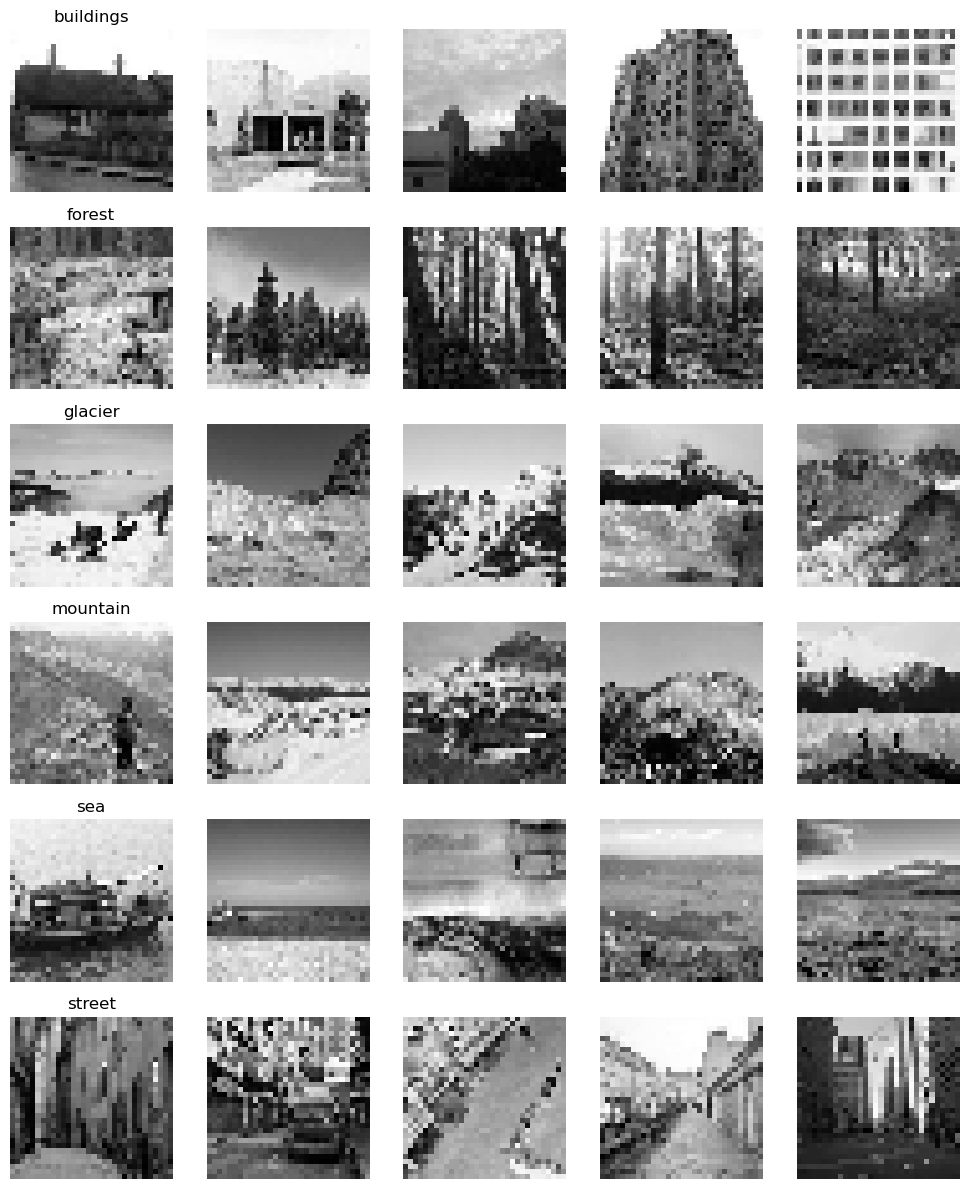


   EXPERIMENTS FOR Intel Image Classification (Optimized)

n=1 | Accuracy=0.2708 | Time=0.167s
n=10 | Accuracy=0.4000 | Time=0.893s
n=50 | Accuracy=0.4688 | Time=6.222s
n=100 | Accuracy=0.4854 | Time=7.637s
n=300 | Accuracy=0.4833 | Time=24.730s


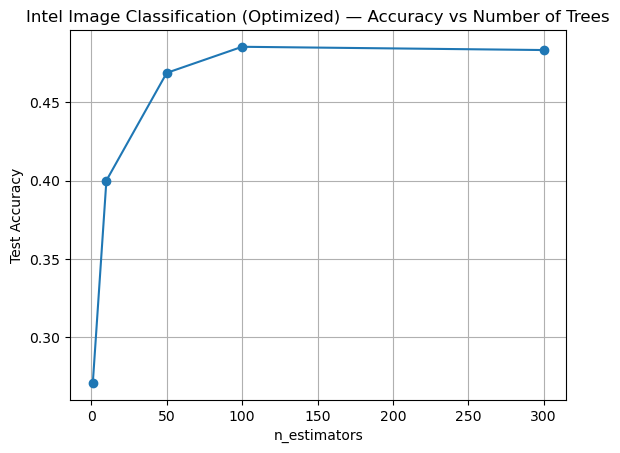


----- COMPARISON -----
Decision Tree: Accuracy=0.3229, Time=7.4799s
Random Forest: Accuracy=0.4542, Time=16.0680s


In [16]:
"""
===========================================================
RANDOM FOREST PROJECT — TABULAR + IMAGE DATASETS
WITHOUT TENSORFLOW (OPENCV + ZIPFILE ONLY)
Optimized for Intel Image Dataset
Auto-detects target column for Heart Dataset
===========================================================
"""

import os
import zipfile
import numpy as np
import pandas as pd
import cv2
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ===========================================================
# 1️⃣ LOAD HEART DISEASE TABULAR DATA
# ===========================================================
def load_heart_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV file not found: {path}")
    
    df = pd.read_csv(path)
    df = df.replace("?", np.nan).dropna()

    # --- Automatically detect target column ---
    target_column = None
    for col in df.columns:
        unique_vals = df[col].dropna().unique()
        if set(unique_vals).issubset({0, 1, 2, 3, 4}):
            target_column = col
            break

    if target_column is None:
        raise ValueError("Could not automatically detect target column in CSV.")

    print(f"Detected target column: '{target_column}'")

    X = df.drop(target_column, axis=1)
    y = df[target_column].astype(int)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ===========================================================
# 2️⃣ LOAD INTEL IMAGE DATASET FROM ZIP (OPENCV ONLY, OPTIMIZED)
# ===========================================================
def load_intel_from_zip(zip_path, extract_to="intel_data", img_size=(32, 32), max_images_per_class=400, grayscale=True):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"ZIP file not found: {zip_path}")

    # Extract ZIP if folder does not exist
    if not os.path.exists(extract_to):
        print("Extracting ZIP...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_to)

    print("Reading image files...")

    # Detect train folder
    train_dir = None
    for root, dirs, _ in os.walk(extract_to):
        for d in dirs:
            if d.lower() in ["buildings", "forest", "mountain", "sea", "street"]:
                train_dir = root
                break
        if train_dir:
            break

    if train_dir is None:
        raise FileNotFoundError("Could not find Intel dataset folders inside ZIP.")

    categories = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

    X, y = [], []

    for label, category in enumerate(categories):
        class_path = os.path.join(train_dir, category)
        count = 0
        print(f"Loading category: {category}")

        for img_name in os.listdir(class_path):
            if count >= max_images_per_class:
                break
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            if grayscale:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(label)
            count += 1

    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y)

    # Flatten for RandomForest
    X = X.reshape(X.shape[0], -1)

    return train_test_split(X, y, test_size=0.2, random_state=42), categories

# ===========================================================
# 3️⃣ DISPLAY SAMPLE IMAGES (FIXED)
# ===========================================================
def display_sample_images(X, y, categories=None, img_size=(32, 32), samples_per_class=5):
    """
    Display sample images per class with correct category names.
    
    X: np.array, flattened or grayscale/color images
    y: labels
    categories: list of class names matching numeric labels
    img_size: (height, width)
    samples_per_class: number of images to display per class
    """
    classes = np.unique(y)
    n_classes = len(classes)
    n_cols = samples_per_class
    n_rows = n_classes

    plt.figure(figsize=(n_cols*2, n_rows*2))

    for row_idx, label in enumerate(classes):
        class_indices = np.where(y == label)[0][:samples_per_class]
        for col_idx, ci in enumerate(class_indices):
            plt.subplot(n_rows, n_cols, row_idx * n_cols + col_idx + 1)
            if X.shape[1] == img_size[0]*img_size[1]:  # grayscale
                plt.imshow(X[ci].reshape(img_size), cmap='gray')
            else:
                plt.imshow(X[ci].reshape(*img_size, 3))
            plt.axis('off')
            # Show category title above first image of each row
            if col_idx == 0:
                title = categories[label] if categories is not None else f"Class {label}"
                plt.title(title)
    plt.tight_layout()
    plt.show()

# ===========================================================
# 4️⃣ EXPERIMENT FUNCTION
# ===========================================================
def run_experiments(X_train, X_test, y_train, y_test, title="Dataset"):
    print("\n=========================================")
    print(f"   EXPERIMENTS FOR {title}")
    print("=========================================\n")
    
    n_estimators_list = [1, 10, 50, 100, 300]
    accuracies = []

    # RandomForest experiments
    for n in n_estimators_list:
        start = time.time()
        rf = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=42)
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        end = time.time()
        acc = accuracy_score(y_test, pred)
        accuracies.append(acc)
        print(f"n={n} | Accuracy={acc:.4f} | Time={(end-start):.3f}s")

    # Plot Accuracy vs n_estimators
    plt.figure()
    plt.plot(n_estimators_list, accuracies, marker='o')
    plt.title(f"{title} — Accuracy vs Number of Trees")
    plt.xlabel("n_estimators")
    plt.ylabel("Test Accuracy")
    plt.grid()
    plt.show()

    # Decision Tree vs RandomForest
    dt = DecisionTreeClassifier()
    start = time.time()
    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)
    dt_time = time.time() - start

    rf = RandomForestClassifier()
    start = time.time()
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    rf_time = time.time() - start

    print("\n----- COMPARISON -----")
    print(f"Decision Tree: Accuracy={accuracy_score(y_test, pred_dt):.4f}, Time={dt_time:.4f}s")
    print(f"Random Forest: Accuracy={accuracy_score(y_test, pred_rf):.4f}, Time={rf_time:.4f}s")

# ===========================================================
# 5️⃣ MAIN
# ===========================================================
def main():
    # Heart Dataset
    X_train, X_test, y_train, y_test = load_heart_dataset("heart_cleveland_upload.csv")
    run_experiments(X_train, X_test, y_train, y_test, title="Heart Disease (Tabular)")

    # Intel Image Dataset (optimized)
    (X_train, X_test, y_train, y_test), categories = load_intel_from_zip(
        "intel image classification.zip",
        img_size=(32, 32),
        max_images_per_class=400,
        grayscale=True
    )

    # Optional: display sample images
    display_sample_images(X_train, y_train, categories=categories, img_size=(32, 32), samples_per_class=5)

    run_experiments(X_train, X_test, y_train, y_test, title="Intel Image Classification (Optimized)")

if __name__ == "__main__":
    main()
